In [5]:
from gen_trace import *
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta
import numpy as np
from collections import defaultdict

In [6]:
REFERENCE_TIME = datetime(2024, 1, 1, 0, 0, 0)

In [7]:
color_list = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]


def plot_arrivals(per_stream_arrivals: dict[str, list[QueryArrival]]):
    num_streams = len(per_stream_arrivals)

    fig, axs = plt.subplots(
        num_streams + 1,
        1,
        figsize=(10, (num_streams + 1) * 2),
        sharex=True,
        sharey=True,
    )

    stream_colors = {
        stream: color_list[i]
        for i, stream in enumerate(per_stream_arrivals.keys())
    }

    # Find the minimum and maximum arrival times across all streams.
    min_arrival_time = min(
        min(arrival.arrival_time for arrival in arrivals)
        for arrivals in per_stream_arrivals.values()
    )
    max_arrival_time = max(
        max(arrival.arrival_time for arrival in arrivals)
        for arrivals in per_stream_arrivals.values()
    )

    min_minute = min_arrival_time.replace(second=0, microsecond=0)
    max_minute = max_arrival_time.replace(second=0, microsecond=0)
    minutes_list = [
        min_minute + timedelta(minutes=m)
        for m in range((max_minute - min_minute).seconds // 60 + 1)
    ]

    # Process each stream.
    for i, (stream, arrivals) in enumerate(per_stream_arrivals.items()):

        ax = axs[i]
        # First create empty per-minute counts for the entire range of minutes
        # from min_arrival_time to max_arrival_time.
        counts = defaultdict(int)
        for arrival in arrivals:
            minute = arrival.arrival_time.replace(second=0, microsecond=0)
            counts[minute] += 1

        # Now plot as a filled line chart.
        counts_list = [counts[minute] for minute in minutes_list]
        ax.fill_between(
            minutes_list,
            counts_list,
            step="post",
            color=stream_colors[stream],
            alpha=0.5,
            label=stream,
        )
        ax.set_ylabel("Arrivals per Minute")
        ax.set_title(f"Arrivals per Minute for Stream: {stream}")

    # Also plot the combined arrivals across all streams in the last subplot.
    combined_counts = defaultdict(int)
    for _, arrivals in per_stream_arrivals.items():
        for arrival in arrivals:
            minute = arrival.arrival_time.replace(second=0, microsecond=0)
            combined_counts[minute] += 1

    combined_counts_list = [combined_counts[minute] for minute in minutes_list]
    axs[-1].fill_between(
        minutes_list,
        combined_counts_list,
        step="post",
        color="black",
        alpha=0.5,
        label="Combined",
    )
    axs[-1].set_ylabel("Arrivals per Minute")
    axs[-1].set_title("Combined Arrivals per Minute")
    axs[-1].set_xlabel("Time")

    plt.tight_layout()
    plt.show()

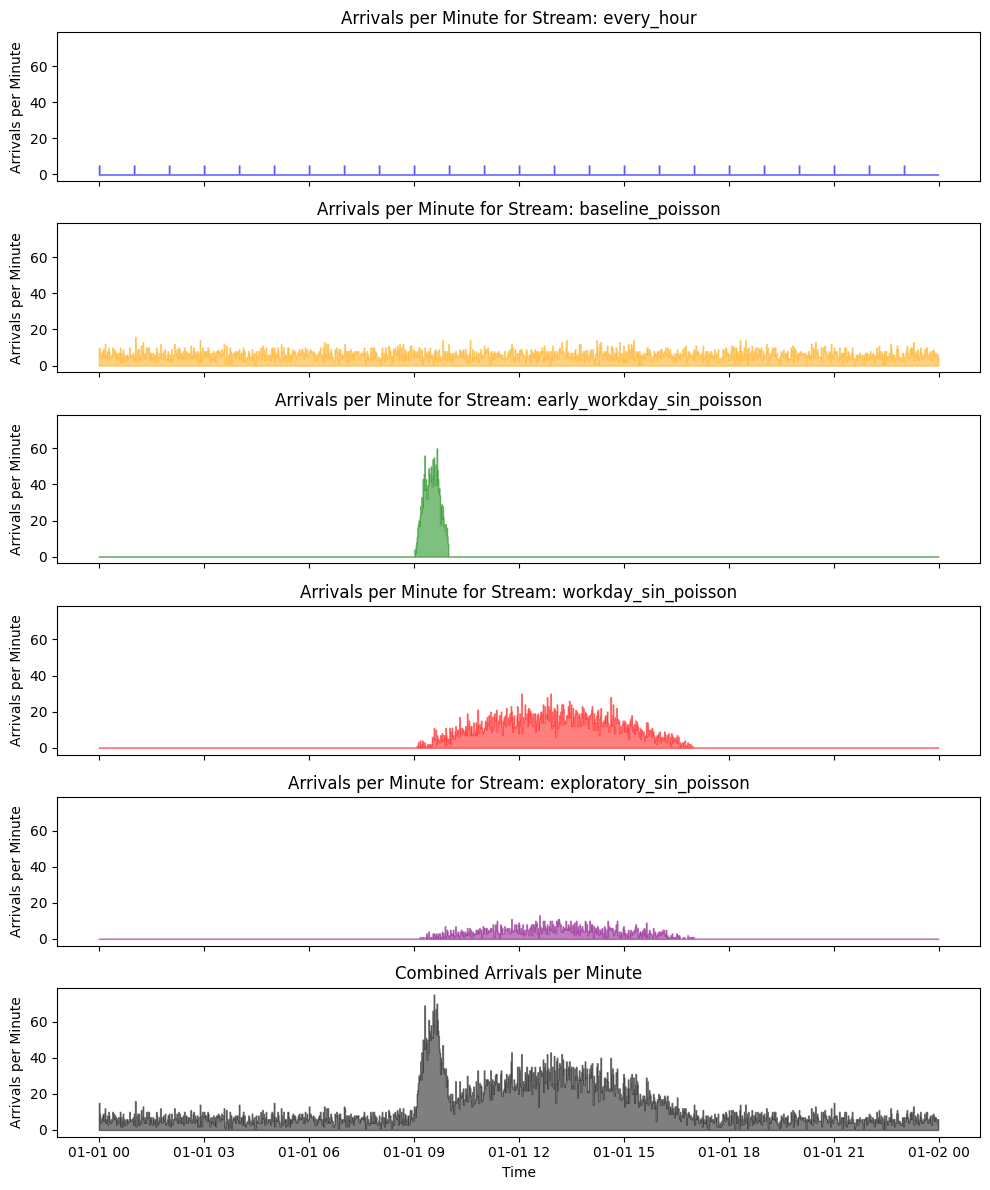

In [8]:
template_list_1 = [f"template_{i}" for i in range(2)]
process_1 = NoisyPeriodicProcess(
    period_s=3600, window_width_s=60, name='every_hour', queries_per_window=5, template_list=template_list_1
)
arrivals_1 = process_1.generate(
    start_time=REFERENCE_TIME,
    end_time=REFERENCE_TIME + timedelta(hours=24)
)

template_list_234 = [f"template_{i}" for i in range(2, 7)]
process_2 = PoissonProcess(rate=0.1, name='baseline_poisson', template_list=template_list_234)
arrivals_2 = process_2.generate(
    start_time=REFERENCE_TIME,
    end_time=REFERENCE_TIME + timedelta(hours=24)
)

process_3 = SinusoidalPoissonProcess(max_rate=0.8, name='early_workday_sin_poisson', template_list=template_list_234)
arrivals_3 = process_3.generate(
    start_time=REFERENCE_TIME + timedelta(hours=9),  # Start at 9 AM
    end_time=REFERENCE_TIME + timedelta(hours=10)    # End at 10 AM
)

process_4 = SinusoidalPoissonProcess(max_rate=0.3, name='workday_sin_poisson', template_list=template_list_234)
arrivals_4 = process_4.generate(
    start_time=REFERENCE_TIME + timedelta(hours=9),  # Start at 9 AM
    end_time=REFERENCE_TIME + timedelta(hours=17)    # End at 5 PM
)


template_list_5 = [f"template_{i}" for i in range(7, 20)]
process_5 = SinusoidalPoissonProcess(max_rate=0.1, name='exploratory_sin_poisson', template_list=template_list_5)
arrivals_5 = process_5.generate(
    start_time=REFERENCE_TIME + timedelta(hours=9),  # Start at 9 AM
    end_time=REFERENCE_TIME + timedelta(hours=17)    # End at 5 PM
)


plot_arrivals(
    {
        process_1.name: arrivals_1,
        process_2.name: arrivals_2,
        process_3.name: arrivals_3,
        process_4.name: arrivals_4,
        process_5.name: arrivals_5,
    }
)

In [9]:
comnbined_arrivals = arrivals_1 + arrivals_2 + arrivals_3 + arrivals_4 + arrivals_5
comnbined_arrivals.sort(key=lambda x: x.arrival_time)


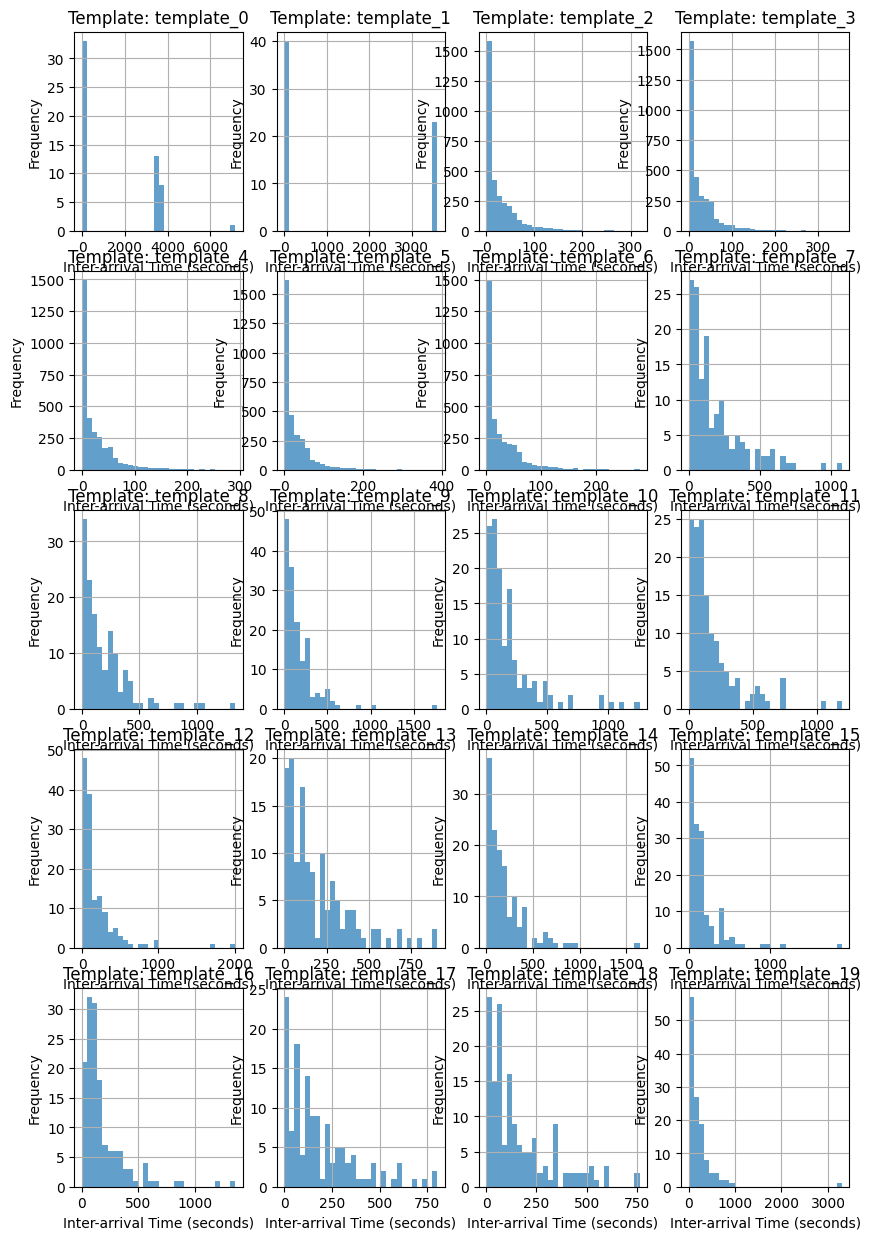

In [10]:
def plot_interarrival_distribution_per_template(arrivals: list[QueryArrival]):
    # Group arrivals by template ID.
    arrivals_by_template = defaultdict(list)
    for arrival in arrivals:
        arrivals_by_template[arrival.template_id].append(arrival)

    num_cols = 4
    num_rows = len(arrivals_by_template) // num_cols + (1 if len(arrivals_by_template) % num_cols > 0 else 0)

    fig, axs = plt.subplots(
        num_rows,
        num_cols,
        figsize=(10, num_rows * 3),

    )

    # For each template, compute inter-arrival times and plot distribution.
    for template_id, template_arrivals in arrivals_by_template.items():
        # Sort arrivals by time.
        template_arrivals.sort(key=lambda x: x.arrival_time)

        # Compute inter-arrival times in seconds.
        inter_arrival_times = []
        for i in range(1, len(template_arrivals)):
            delta = (template_arrivals[i].arrival_time - template_arrivals[i-1].arrival_time).total_seconds()
            inter_arrival_times.append(delta)

        # Plot histogram of inter-arrival times.
        ax = axs[int(template_id.split('_')[1]) // 4][int(template_id.split('_')[1]) % 4]
        ax.hist(inter_arrival_times, bins=30, alpha=0.7)
        ax.set_title(f"Template: {template_id}")
        ax.set_xlabel("Inter-arrival Time (seconds)")
        ax.set_ylabel("Frequency")
        ax.grid(True)
    plt.show()

plot_interarrival_distribution_per_template(comnbined_arrivals)

In [92]:
from autoslo.forecasting.arrival_classifier import ArrivalClassifier
classifier = ArrivalClassifier(comnbined_arrivals)
template_windowness_results = classifier.classify_arrivals()

Analyzing 20 distinct templates

Template template_0: Elapsed Time: 0.03 s, Result: {'num_samples': 56, 'is_windowed': True, 'reason': None, 'period_s': 3600.0, 'active_length_s': 58.53711299999836, 'idle_ratio': 0.9837396908333338, 'on_window_rel_start_s': 3599.097353000001, 'p_value': 0.009900990099009901}
Template template_1: Elapsed Time: 0.02 s, Result: {'num_samples': 64, 'is_windowed': True, 'reason': None, 'period_s': 3600.0, 'active_length_s': 58.53522700000018, 'idle_ratio': 0.9837402147222222, 'on_window_rel_start_s': 0.0, 'p_value': 0.009900990099009901}
Template template_10: Elapsed Time: 0.00 s, Result: {'num_samples': 137, 'is_windowed': False, 'reason': 'No periods with okay idle ratio (>= 0.9)', 'period_s': None, 'active_length_s': None, 'idle_ratio': None, 'p_value': None}
Template template_11: Elapsed Time: 0.00 s, Result: {'num_samples': 142, 'is_windowed': False, 'reason': 'No periods with okay idle ratio (>= 0.9)', 'period_s': None, 'active_length_s': None, 'idle_ratio': None, 'p_value': None}
Te

In [83]:
import numpy as np
from autoslo.forecasting.windowed_template_detector import WindowedTemplateClassifier
template_windowness_results = {}

distinct_templates = sorted(list(set(arrival.template_id for arrival in comnbined_arrivals)))
for template_id in distinct_templates:
    template_timestamps = np.array([
        (arrival.arrival_time - REFERENCE_TIME).total_seconds()
        for arrival in comnbined_arrivals
        if arrival.template_id == template_id
    ])

    print(f"Analyzing template {template_id} with {len(template_timestamps)} arrivals...")
    start_time = datetime.now()
    classifier = WindowedTemplateClassifier(template_timestamps)
    result = classifier.classify()
    end_time = datetime.now()
    elapsed = (end_time - start_time).total_seconds()
    print(f"\tFinished in {elapsed:.2f} seconds.")
    print(f"\tResult: {result}")
    template_windowness_results[template_id] = result

Analyzing template template_0 with 56 arrivals...
	Finished in 0.03 seconds.
	Result: {'num_samples': 56, 'is_windowed': True, 'reason': None, 'period_s': 3600.0, 'active_length_s': 58.53711300000195, 'idle_ratio': 0.9837396908333328, 'p_value': 0.009900990099009901}
Analyzing template template_1 with 64 arrivals...
	Finished in 0.02 seconds.
	Result: {'num_samples': 64, 'is_windowed': True, 'reason': None, 'period_s': 3600.0, 'active_length_s': 58.53522699999818, 'idle_ratio': 0.9837402147222227, 'p_value': 0.009900990099009901}
Analyzing template template_10 with 137 arrivals...
	Finished in 0.00 seconds.
	Result: {'num_samples': 137, 'is_windowed': False, 'reason': 'No periods with okay idle ratio (>= 0.9)', 'period_s': None, 'active_length_s': None, 'idle_ratio': None, 'p_value': None}
Analyzing template template_11 with 142 arrivals...
	Finished in 0.00 seconds.
	Result: {'num_samples': 142, 'is_windowed': False, 'reason': 'No periods with okay idle ratio (>= 0.9)', 'period_s': No

In [60]:
rng = np.random.default_rng(0)

rng.poisson(lam=DAY, size=56)

array([86516, 85645, 86695, 86489, 86436, 86698, 86758, 86602, 86768,
       86226, 85435, 86546, 86497, 86560, 86563, 86029, 86421, 86388,
       86966, 86459, 86479, 86309, 86153, 85908, 86663, 86793, 86260,
       86359, 86156, 86320, 85929, 86225, 86286, 86509, 86351, 86400,
       87058, 86631, 86424, 86329, 86584, 85990, 86935, 86821, 86383,
       86681, 86193, 86353, 86496, 86592, 86631, 86943, 86733, 86267,
       86186, 86817])

In [ ]:
# Using rng.poisson, draw `size` sample times, such that the me